In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Kode ini digunakan untuk memuat dataset citra dari beberapa folder kelas. Setiap gambar dibaca menggunakan OpenCV, kemudian dikonversi menjadi grayscale dan diubah ukurannya menjadi 256×256 piksel agar seluruh data memiliki dimensi yang sama. Gambar yang telah diproses disimpan ke dalam variabel `data`, sedangkan nama foldernya disimpan sebagai `labels` sebagai penanda kelas. Setelah seluruh gambar diproses, data dan label diubah menjadi array NumPy untuk memudahkan proses pengolahan citra atau klasifikasi.

In [6]:
data = []
labels = []
file_name = []

target_size = (256, 256)
dataset_path = "/content/drive/MyDrive/PROJECT_PCD/Dataset"

# Sort folder kelas
for sub_folder in sorted(os.listdir(dataset_path)):

    sub_folder_path = os.path.join(dataset_path, sub_folder)

    # Pastikan yang dibaca hanya folder
    if os.path.isdir(sub_folder_path):

        # Sort file gambar
        for filename in sorted(os.listdir(sub_folder_path)):

            img_path = os.path.join(sub_folder_path, filename)

            img = cv.imread(img_path)

            # Lewati jika gambar gagal dibaca
            if img is None:
                print(f"Gagal membaca: {img_path}")
                continue

            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, target_size)

            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

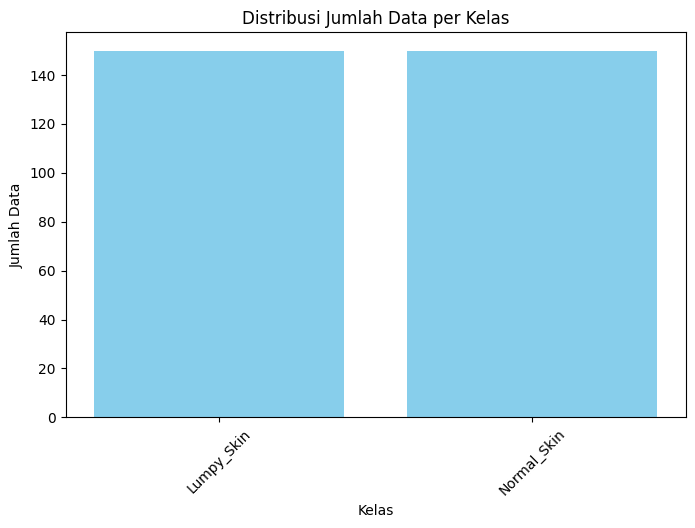

In [7]:
# Menampilkan jumlah data per kelas
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique_labels, counts, color='skyblue')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Jumlah Data per Kelas")
plt.xticks(rotation=45)
plt.show()

Kode ini digunakan untuk **menampilkan histogram distribusi intensitas piksel** dari beberapa sampel citra pada kelas **Lumpy Skin** dan **Normal Skin**. Pertama, program memisahkan data citra berdasarkan labelnya ke dalam variabel `Lumpy_Skin` dan `Normal_skin`. Selanjutnya, program mengambil maksimal lima gambar dari masing-masing kelas dan membuat histogram menggunakan `plt.hist()`. Histogram tersebut menunjukkan sebaran nilai intensitas piksel dari 0 (gelap) hingga 255 (terang), sehingga dapat digunakan untuk menganalisis kondisi pencahayaan dan karakteristik citra pada setiap kelas. Sumbu X menunjukkan intensitas piksel, sedangkan sumbu Y menunjukkan frekuensi kemunculan piksel pada intensitas tersebut. Dengan membandingkan histogram kedua kelas, dapat diamati perbedaan distribusi tingkat kecerahan yang mungkin menjadi salah satu ciri pembeda antara citra **Lumpy Skin** dan **Normal Skin**.

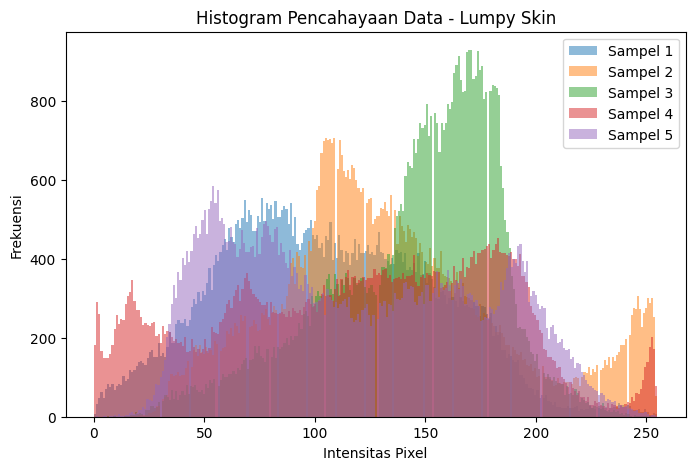

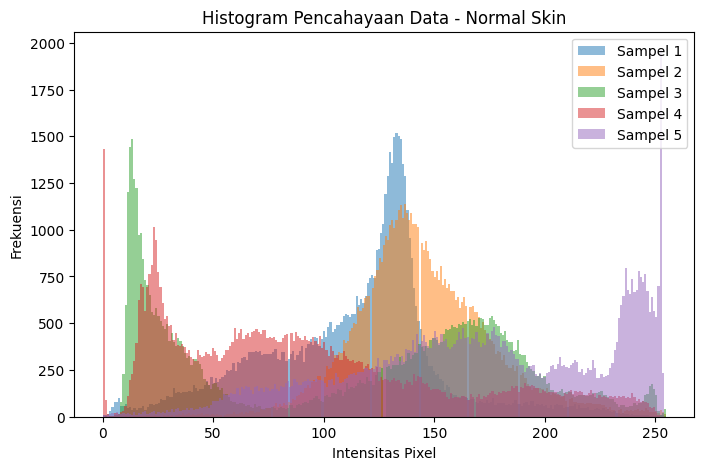

In [8]:
Lumpy_Skin = [data[i] for i in range(len(labels)) if labels[i] == "Lumpy_Skin"]
Normal_skin = [data[i] for i in range(len(labels)) if labels[i] == "Normal_Skin"]

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Lumpy_Skin))):
    img = Lumpy_Skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Lumpy Skin")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for i in range(min(5, len(Normal_skin))):
    img = Normal_skin[i]
    plt.hist(img.ravel(), bins=256, alpha=0.5, label=f'Sampel {i+1}')
plt.xlabel("Intensitas Pixel")
plt.ylabel("Frekuensi")
plt.title("Histogram Pencahayaan Data - Normal Skin")
plt.legend()
plt.show()

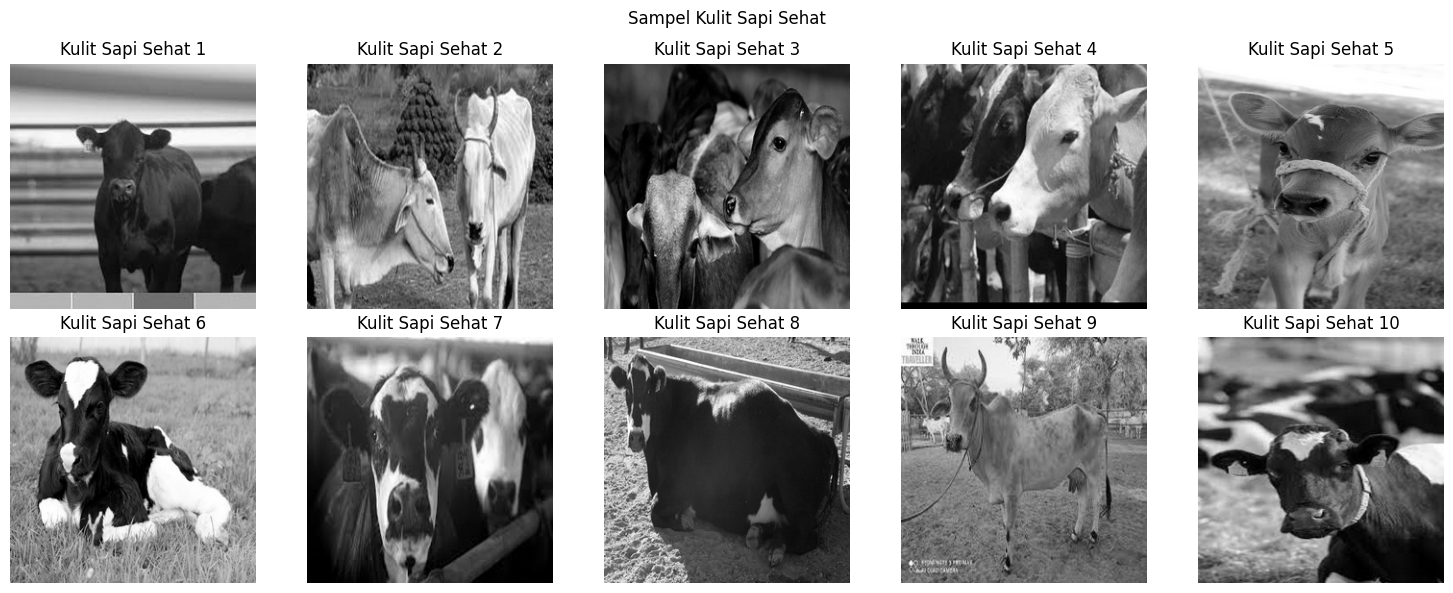

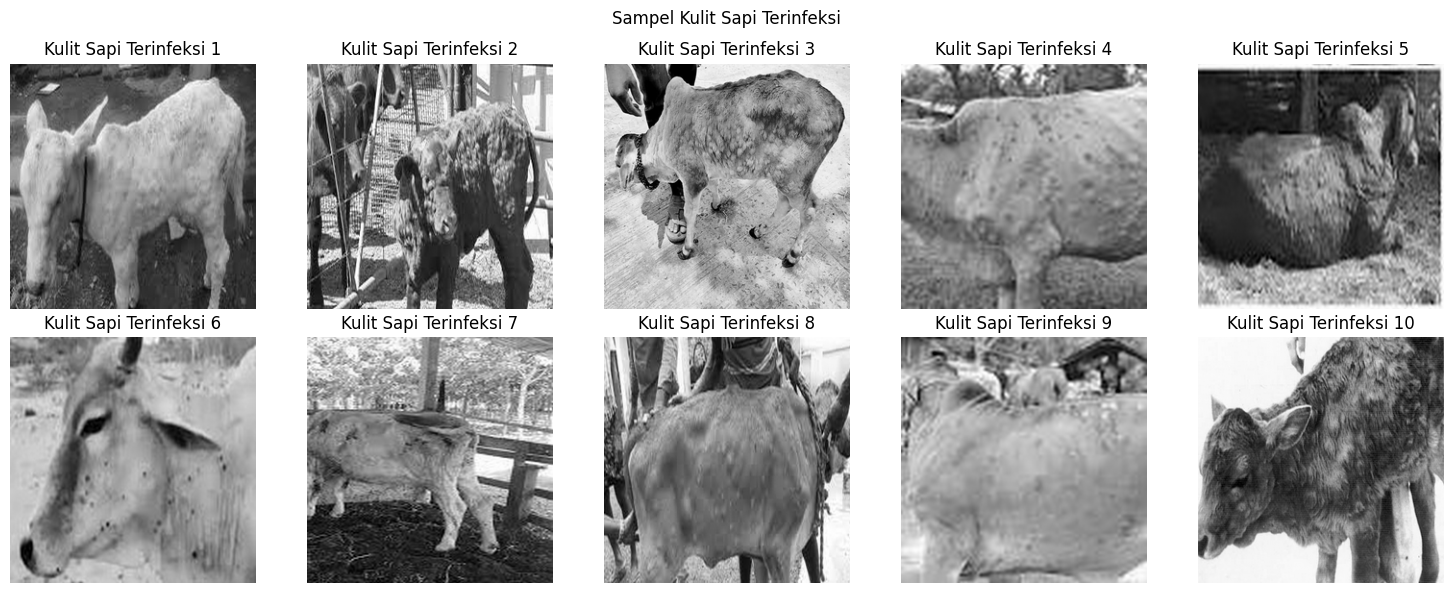

In [10]:
import random

# Menampilkan sampel kulit sapi sehat
random_normal = random.sample(Normal_skin, min(10, len(Normal_skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_normal))):
    axes[i].imshow(random_normal[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Sehat {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Sehat")
plt.tight_layout()
plt.show()

# Menampilkan sampel kulit sapi terinfeksi
random_lumpy = random.sample(Lumpy_Skin, min(10, len(Lumpy_Skin)))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(random_lumpy))):
    axes[i].imshow(random_lumpy[i], cmap="gray")
    axes[i].set_title(f"Kulit Sapi Terinfeksi {i+1}")
    axes[i].axis("off")
plt.suptitle("Sampel Kulit Sapi Terinfeksi")
plt.tight_layout()
plt.show()

Kode dibawah ini digunakan untuk melakukan augmentasi data pada citra ikan untuk memperbanyak dataset dengan berbagai transformasi gambar, yang bertujuan meningkatkan variasi data dan mencegah overfitting saat pelatihan model machine learning. Prosesnya dimulai dengan membuat dictionary augmented untuk menyimpan tiga komponen: data citra hasil augmentasi, label kelas, dan nama file. Untuk setiap gambar asli dalam dataset (data[i]), dilakukan empat jenis transformasi: (1) flip horizontal menggunakan cv.flip(img, 1), (2) flip vertikal dengan cv.flip(img, 0), (3) rotasi 90 derajat searah jarum jam melalui cv.ROTATE_90_CLOCKWISE, dan (4) rotasi 180 derajat dengan cv.ROTATE_180. Setiap citra hasil transformasi disimpan beserta label aslinya dan nama file yang diberi suffix sesuai jenis augmentasi (contoh: filename_flip_h). Terakhir, kode menampilkan perbandingan jumlah data sebelum dan setelah augmentasi, dimana dataset akan bertambah menjadi 5 kali lipat (1 gambar asli + 4 hasil augmentasi) untuk setiap citra, sehingga memperkaya variasi data tanpa mengubah label kelas yang sesungguhnya. Kami melakukan augmentasi ini dikarenakan pada saat mendapatkan dataset dari kaggle terdapat banyak citra yang sangat anomali sehingga citra yang sisa kami peroleh itu sangat sedikit maka dari itu kami melakukan augmentasi untuk keperluan lebih lanjut.

In [11]:
augmented = {
    'data': [],
    'labels': [],
    'filenames': []
}

# Proses augmentasi
for i in range(len(data)):
    img = data[i]
    label = labels[i]
    filename = file_name[i]

    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)

    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)

    # 3. Rotasi 90 Derajat
    img_rot_90 = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)

    # 4. Rotasi 180 Derajat
    img_rot_180 = cv.rotate(img, cv.ROTATE_180)

    # Simpan semua hasil ke dalam dictionary 'augmented'
    augmented_images = [
        (img_flip_h, 'flip_h'),
        (img_flip_v, 'flip_v'),
        (img_rot_90, 'rot_90'),
        (img_rot_180, 'rot_180'),
    ]

    for img_aug, suffix in augmented_images:
        augmented['data'].append(img_aug)
        augmented['labels'].append(label)
        augmented['filenames'].append(f"{filename}_{suffix}")

# Tampilkan hasil
print("Jumlah data sebelum augmentasi:", len(data))
print("Jumlah data setelah augmentasi:", len(augmented['data']))

Jumlah data sebelum augmentasi: 300
Jumlah data setelah augmentasi: 1200


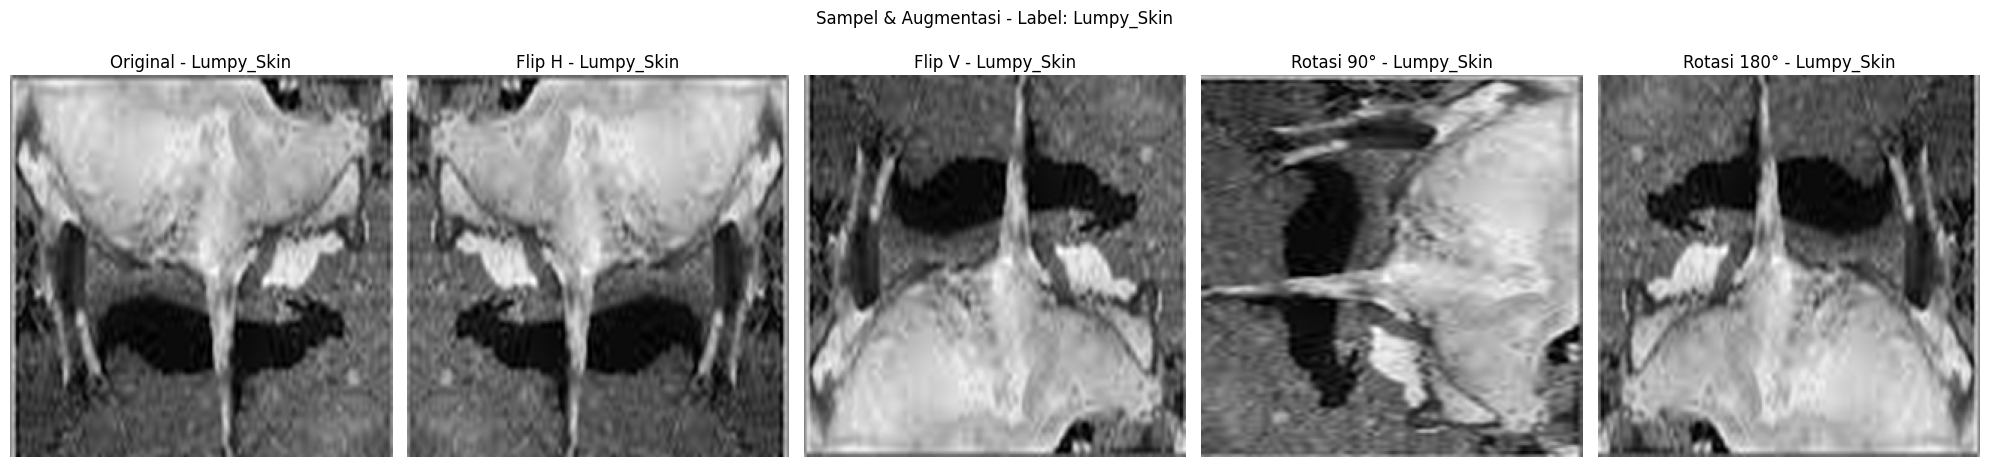

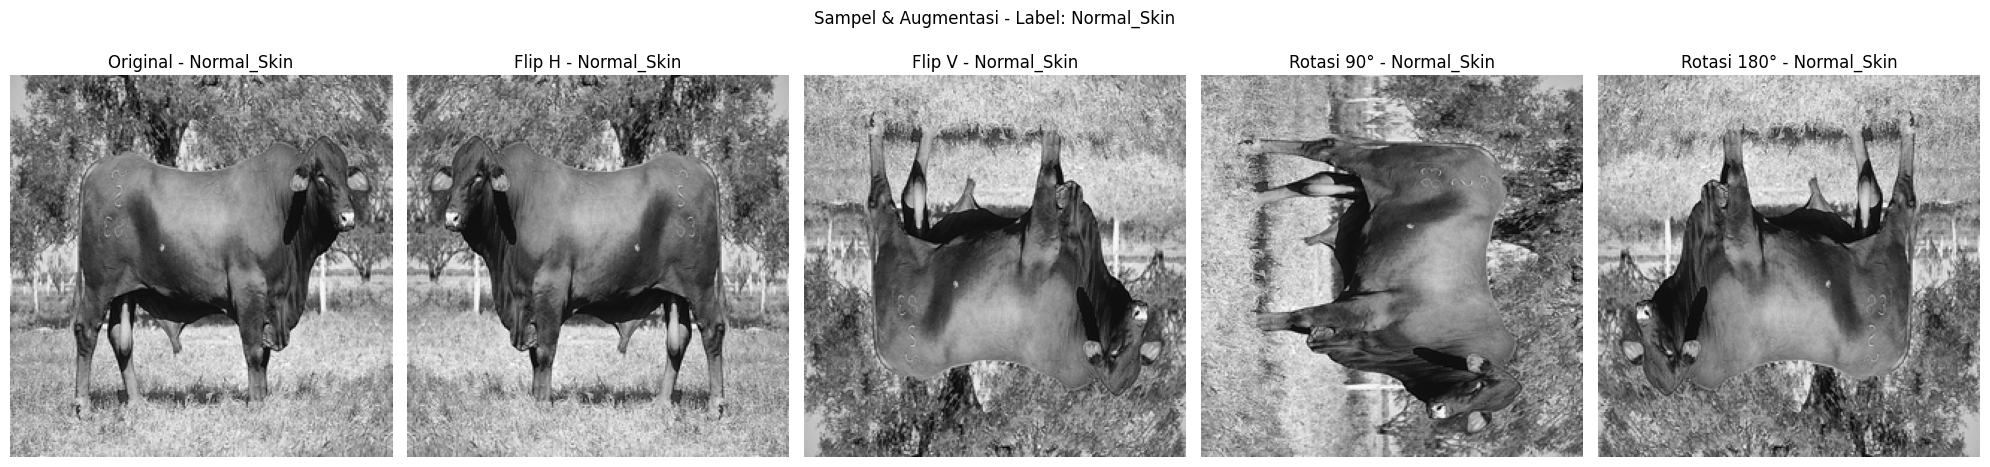

In [16]:
import random

# Ambil label unik dari data yang telah di-augmentasi
unique_labels = np.unique(augmented['labels'])

for label in unique_labels:
    # Ambil semua gambar yang label-nya sama
    samples = [augmented['data'][i] for i in range(len(augmented['labels'])) if augmented['labels'][i] == label]

    if len(samples) > 0:
        sample_img = random.choice(samples)  # Ambil satu contoh gambar

        # Siapkan tampilan
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        augment_titles = ["Original", "Flip H", "Flip V", "Rotasi 90°", "Rotasi 180°"]

        # Daftar gambar hasil augmentasi tanpa translasi
        augmentations = [
            sample_img,
            cv.flip(sample_img, 1),
            cv.flip(sample_img, 0),
            cv.rotate(sample_img, cv.ROTATE_90_CLOCKWISE),
            cv.rotate(sample_img, cv.ROTATE_180)
        ]

        # Tampilkan semua hasil dalam satu baris
        for i in range(5):
            axes[i].imshow(augmentations[i], cmap="gray")
            axes[i].set_title(f"{augment_titles[i]} - {label}")
            axes[i].axis("off")

        plt.suptitle(f"Sampel & Augmentasi - Label: {label}")
        plt.tight_layout()
        plt.show()


Fungsi `normalize()` digunakan untuk menyesuaikan rentang nilai intensitas piksel citra ke rentang **0–255**. Proses ini dilakukan dengan mencari nilai piksel minimum dan maksimum, kemudian setiap piksel diskalakan menggunakan rumus normalisasi. Jika seluruh piksel memiliki nilai yang sama sehingga tidak terdapat rentang intensitas, fungsi akan mengembalikan citra kosong untuk menghindari pembagian dengan nol. Hasil akhirnya dikonversi kembali ke tipe data `uint8`.

Sementara itu, fungsi `histogram_equalization()` digunakan untuk meningkatkan kontras citra dengan metode **Histogram Equalization** yang dibuat secara manual. Fungsi ini menghitung histogram citra, kemudian membentuk **Cumulative Distribution Function (CDF)** untuk memperoleh distribusi kumulatif intensitas piksel. Nilai CDF tersebut digunakan untuk memetakan ulang intensitas piksel sehingga distribusinya menjadi lebih merata pada rentang 0–255. Dengan demikian, detail citra yang sebelumnya kurang terlihat akibat kontras rendah dapat menjadi lebih jelas dan mudah dianalisis.

In [17]:
def normalize(img):
    img = img.astype(np.float32)
    min_val = np.min(img)
    max_val = np.max(img)
    if max_val - min_val == 0:
        return np.zeros_like(img, dtype=np.uint8)
    norm_img = (img - min_val) / (max_val - min_val) * 255
    return norm_img.astype(np.uint8)

def histogram_equalization(img):
    # Histogram Equalization secara manual
    hist, bins = np.histogram(img.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_min = cdf_masked.min()
    cdf_max = cdf_masked.max()
    cdf_masked = (cdf_masked - cdf_min) * 255 / (cdf_max - cdf_min)
    cdf_final = np.ma.filled(cdf_masked, 0).astype('uint8')
    img_eq = cdf_final[img]
    return img_eq


Fungsi `prepro1()` digunakan untuk melakukan **tahap preprocessing citra** dengan menggabungkan dua proses, yaitu **normalisasi** dan **histogram equalization**.

In [18]:
def prepro1(img):
    norm = normalize(img)
    eq = histogram_equalization(norm)
    return eq

In [19]:
import random

# Inisialisasi list untuk menyimpan hasil preprocessing
dataPreprocessed_1 = []

# Ambil data hasil augmentasi
augmented_data = augmented['data']

# Lakukan preprocessing untuk masing-masing percobaan
for img in augmented_data:
    dataPreprocessed_1.append(prepro1(img))
dataPreprocessed = dataPreprocessed_1

dataPreprocessed_healthy = []
dataPreprocessed_infected = []

labels = augmented['labels']

# Pisahkan data berdasarkan label
for img, label in zip(dataPreprocessed, labels):
    if label == "Normal_Skin":
        dataPreprocessed_healthy.append(img)
    elif label == "Lumpy_Skin":
        dataPreprocessed_infected.append(img)

# Ambil 100 sampel random dari masing-masing kategori
random_healthy  = random.sample(dataPreprocessed_healthy, min(100, len(dataPreprocessed_healthy)))
random_infected = random.sample(dataPreprocessed_infected, min(100, len(dataPreprocessed_infected)))

# Tampilkan dalam satu figure
# Healthy: 10 baris x 10 kolom, Infected: 10 baris x 10 kolom = total 20 baris x 10 kolom
fig, axes = plt.subplots(20, 10, figsize=(20, 40))

# Baris 0-9: Healthy
for i in range(100):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(random_healthy[i], cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Healthy {i+1}", fontsize=7)

# Baris 10-19: Infected
for i in range(100):
    row = (i // 10) + 10
    col = i % 10
    axes[row, col].imshow(random_infected[i], cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Lumpy {i+1}", fontsize=7)


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Fungsi `glcm()` digunakan untuk membentuk **Gray Level Co-occurrence Matrix (GLCM)** dari sebuah citra. GLCM merupakan metode ekstraksi fitur tekstur yang menggambarkan hubungan kemunculan pasangan piksel dengan tingkat keabuan tertentu pada jarak dan arah tertentu. Pada fungsi ini, pengguna dapat memilih arah perhitungan sebesar **0°, 45°, 90°, atau 135°**, yang kemudian dikonversi ke satuan radian sesuai kebutuhan fungsi `graycomatrix()`. Selanjutnya, fungsi `graycomatrix()` digunakan untuk menghitung matriks GLCM dengan jarak antar piksel sebesar 1, jumlah level keabuan 256, serta opsi `symmetric=True` dan `normed=True` agar matriks bersifat simetris dan ternormalisasi. Hasil akhirnya berupa matriks GLCM yang dapat digunakan untuk menghitung berbagai fitur tekstur seperti **contrast, correlation, energy, homogeneity**, dan fitur tekstur lainnya.

In [20]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi `correlation()` digunakan untuk menghitung **fitur Correlation** dari matriks **GLCM (Gray Level Co-occurrence Matrix)**. Perhitungan dilakukan menggunakan fungsi `graycoprops()` dengan parameter `'correlation'`, yang mengukur tingkat hubungan atau ketergantungan linier antara pasangan piksel pada citra. Nilai correlation yang tinggi menunjukkan bahwa tingkat keabuan piksel tetangga memiliki hubungan yang kuat dan teratur, sedangkan nilai yang rendah menunjukkan hubungan yang lebih lemah atau acak. Fungsi ini mengembalikan satu nilai correlation dari matriks GLCM yang nantinya dapat digunakan sebagai fitur tekstur dalam proses analisis atau klasifikasi citra.

In [21]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Fungsi `dissimilarity()` digunakan untuk menghitung nilai **Dissimilarity** dari matriks GLCM. Fitur ini mengukur tingkat perbedaan intensitas antara pasangan piksel yang bertetangga dalam citra. Semakin tinggi nilai dissimilarity, semakin besar variasi atau ketidaksamaan tekstur pada citra, sedangkan nilai yang rendah menunjukkan tekstur yang lebih seragam. Hasil perhitungan ini dapat digunakan sebagai salah satu fitur tekstur dalam proses analisis atau klasifikasi citra.

In [22]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Fungsi `homogenity()` digunakan untuk menghitung nilai **Homogeneity** dari matriks GLCM. Fitur ini mengukur tingkat keseragaman atau kemiripan intensitas antar piksel yang bertetangga dalam citra. Nilai homogeneity yang tinggi menunjukkan tekstur yang lebih halus dan seragam, sedangkan nilai yang rendah menunjukkan tekstur yang lebih bervariasi. Fitur ini sering digunakan dalam ekstraksi tekstur untuk analisis dan klasifikasi citra.

In [23]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Fungsi `contrast()` digunakan untuk menghitung nilai **Contrast** dari matriks GLCM. Fitur ini mengukur tingkat perbedaan intensitas antara piksel yang bertetangga dalam citra. Nilai contrast yang tinggi menunjukkan adanya perbedaan intensitas yang besar sehingga tekstur terlihat lebih kasar, sedangkan nilai yang rendah menunjukkan tekstur yang lebih halus dan seragam. Fitur ini sering digunakan untuk menganalisis karakteristik tekstur pada citra.

In [24]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Fungsi `ASM()` digunakan untuk menghitung nilai **Angular Second Moment (ASM)** dari matriks GLCM. Fitur ini mengukur tingkat keseragaman distribusi pasangan piksel dalam citra. Nilai ASM yang tinggi menunjukkan tekstur yang lebih homogen dan teratur, sedangkan nilai yang rendah menunjukkan tekstur yang lebih kompleks dan bervariasi. Fitur ini sering digunakan sebagai indikator keteraturan tekstur pada proses analisis dan klasifikasi citra.

In [25]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Fungsi `energy()` digunakan untuk menghitung nilai **Energy** dari matriks GLCM. Fitur ini mengukur tingkat keseragaman atau keteraturan tekstur pada citra. Nilai energy yang tinggi menunjukkan tekstur yang lebih homogen dan teratur, sedangkan nilai yang rendah menunjukkan tekstur yang lebih kompleks dan bervariasi. Fitur ini sering digunakan sebagai salah satu parameter ekstraksi tekstur dalam analisis dan klasifikasi citra.

In [26]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Fungsi `entropyGlcm()` digunakan untuk menghitung nilai **Entropy** dari matriks GLCM. Fitur ini mengukur tingkat ketidakteraturan atau kompleksitas tekstur pada citra. Semakin tinggi nilai entropy, semakin acak dan kompleks tekstur citra tersebut, sedangkan nilai yang rendah menunjukkan tekstur yang lebih teratur dan homogen. Pada fungsi ini, matriks GLCM diubah menjadi array satu dimensi menggunakan `ravel()`, kemudian nilai entropinya dihitung dengan fungsi `entropy()`.

In [27]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini digunakan untuk menghitung **matriks GLCM** dari setiap citra yang telah melalui tahap preprocessing (`dataPreprocessed`) pada empat arah yang berbeda, yaitu **0°, 45°, 90°, dan 135°**. Untuk setiap citra, fungsi `glcm()` dipanggil sesuai sudut yang ditentukan, kemudian hasil matriks GLCM disimpan ke dalam list `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Dengan demikian, setiap citra memiliki empat matriks GLCM yang merepresentasikan karakteristik teksturnya dari berbagai arah, sehingga informasi tekstur yang diperoleh menjadi lebih lengkap untuk proses ekstraksi fitur dan klasifikasi.

In [28]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kode ini digunakan untuk membuat sejumlah **list kosong** yang akan digunakan untuk menyimpan hasil ekstraksi fitur tekstur dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**. Fitur yang disimpan meliputi **Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy,** dan **Correlation**. Setiap fitur memiliki empat list terpisah sesuai arah perhitungan GLCM. Nantinya, nilai fitur yang dihitung dari setiap citra akan dimasukkan ke dalam list yang sesuai, sehingga dapat digunakan sebagai data masukan pada proses analisis atau klasifikasi citra.

In [29]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Kode ini digunakan untuk menghitung fitur **Correlation** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `correlation()` diterapkan pada matriks GLCM yang tersimpan di `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Hasil perhitungan kemudian disimpan ke dalam list `correlation0`, `correlation45`, `correlation90`, dan `correlation135` sesuai dengan arah masing-masing. Dengan demikian, diperoleh nilai correlation dari setiap citra pada berbagai arah yang dapat digunakan sebagai fitur tekstur dalam proses analisis atau klasifikasi citra.

In [30]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Kode ini digunakan untuk menghitung fitur **Contrast** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `contrast()` diterapkan pada matriks GLCM yang tersimpan di masing-masing arah, kemudian hasilnya disimpan ke dalam list `Kontras0`, `Kontras45`, `Kontras90`, dan `Kontras135`. Nilai contrast yang diperoleh menggambarkan tingkat perbedaan intensitas antar piksel bertetangga pada citra dan digunakan sebagai salah satu fitur tekstur dalam proses analisis atau klasifikasi citra.

In [31]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Kode ini digunakan untuk menghitung fitur **Dissimilarity** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `dissimilarity()` diterapkan pada matriks GLCM dari masing-masing arah, kemudian hasilnya disimpan ke dalam list `dissimilarity0`, `dissimilarity45`, `dissimilarity90`, dan `dissimilarity135`. Nilai dissimilarity menunjukkan tingkat perbedaan intensitas antar piksel yang bertetangga, sehingga dapat digunakan sebagai salah satu fitur tekstur dalam proses analisis atau klasifikasi citra.

In [32]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Kode ini digunakan untuk menghitung fitur **Homogeneity** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `homogenity()` diterapkan pada matriks GLCM dari masing-masing arah, kemudian hasilnya disimpan ke dalam list `homogenity0`, `homogenity45`, `homogenity90`, dan `homogenity135`. Nilai homogeneity menunjukkan tingkat keseragaman tekstur pada citra, di mana nilai yang lebih tinggi menandakan tekstur yang lebih homogen dan teratur.

In [33]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Kode ini digunakan untuk menghitung fitur **Entropy** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `entropyGlcm()` diterapkan pada matriks GLCM dari masing-masing arah, kemudian hasilnya disimpan ke dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`. Nilai entropy menunjukkan tingkat ketidakteraturan atau kompleksitas tekstur citra, di mana nilai yang lebih tinggi menandakan tekstur yang lebih acak dan kompleks, sedangkan nilai yang lebih rendah menunjukkan tekstur yang lebih teratur.

In [34]:
for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Kode ini digunakan untuk menghitung fitur **ASM (Angular Second Moment)** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `ASM()` diterapkan pada matriks GLCM dari masing-masing arah, kemudian hasilnya disimpan ke dalam list `ASM0`, `ASM45`, `ASM90`, dan `ASM135`. Nilai ASM menunjukkan tingkat keseragaman atau keteraturan tekstur citra, di mana nilai yang lebih tinggi menandakan tekstur yang lebih homogen dan teratur.

In [35]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Kode ini digunakan untuk menghitung fitur **Energy** dari matriks GLCM pada empat arah, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra yang telah diproses. Pada setiap iterasi, fungsi `energy()` diterapkan pada matriks GLCM dari masing-masing arah, kemudian hasilnya disimpan ke dalam list `energy0`, `energy45`, `energy90`, dan `energy135`. Nilai energy menunjukkan tingkat keseragaman dan keteraturan tekstur citra, di mana nilai yang lebih tinggi menunjukkan tekstur yang lebih homogen, sedangkan nilai yang lebih rendah menunjukkan tekstur yang lebih kompleks dan bervariasi.

In [36]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode ini digunakan untuk **menggabungkan seluruh hasil ekstraksi fitur GLCM ke dalam sebuah tabel (DataFrame)**. Data yang dimasukkan meliputi nama file (`Filename`), label kelas (`Label`), serta fitur tekstur **Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy,** dan **Correlation** pada empat arah pengamatan (**0°, 45°, 90°, dan 135°**). Seluruh data tersebut disimpan dalam dictionary `dataTable`, kemudian diubah menjadi DataFrame menggunakan `pd.DataFrame()`. Selanjutnya, DataFrame disimpan ke file CSV bernama **`hasil_ekstraksi_1.csv`** menggunakan `to_csv()`. Terakhir, file CSV dibaca kembali dengan `pd.read_csv()` dan ditampilkan melalui variabel `hasilEkstrak`. Tabel ini menjadi dataset fitur yang siap digunakan untuk proses analisis data atau pelatihan model klasifikasi.

In [37]:
dataTable = {'Filename': augmented['filenames'], 'Label': augmented['labels'],
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Lumpy_Skin_102.png_flip_h,Lumpy_Skin,1111.473621,1923.163060,905.902482,1632.460777,0.109183,0.060824,0.102492,0.068042,...,0.000157,0.000111,0.012595,0.009882,0.012532,0.010516,0.897328,0.822093,0.916166,0.848984
1,Lumpy_Skin_102.png_flip_v,Lumpy_Skin,1111.473621,1923.163060,905.902482,1632.460777,0.109183,0.060824,0.102492,0.068042,...,0.000157,0.000111,0.012595,0.009882,0.012532,0.010516,0.897328,0.822093,0.916166,0.848984
2,Lumpy_Skin_102.png_rot_90,Lumpy_Skin,905.902482,1923.163060,1111.473621,1632.460777,0.102492,0.060824,0.109183,0.068042,...,0.000159,0.000111,0.012532,0.009882,0.012595,0.010516,0.916166,0.822093,0.897328,0.848984
3,Lumpy_Skin_102.png_rot_180,Lumpy_Skin,1111.473621,1632.460777,905.902482,1923.163060,0.109183,0.068042,0.102492,0.060824,...,0.000157,0.000098,0.012595,0.010516,0.012532,0.009882,0.897328,0.848984,0.916166,0.822093
4,Lumpy_Skin_103.png_flip_h,Lumpy_Skin,867.840365,1013.170027,252.980208,997.657040,0.145627,0.127359,0.215492,0.125089,...,0.000451,0.000227,0.016337,0.015291,0.021238,0.015059,0.919482,0.905857,0.976564,0.907299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Normal_Skin_97.png_rot_180,Normal_Skin,920.059544,1182.381392,468.988174,1177.901361,0.105854,0.095248,0.154255,0.093314,...,0.000549,0.000322,0.019199,0.018099,0.023436,0.017934,0.915533,0.891395,0.956915,0.891805
1196,Normal_Skin_98.png_flip_h,Normal_Skin,1702.624556,2032.660115,1228.473269,2097.222345,0.149433,0.141141,0.174696,0.138793,...,0.000575,0.000486,0.023118,0.021999,0.023983,0.022038,0.843033,0.812224,0.886460,0.806263
1197,Normal_Skin_98.png_flip_v,Normal_Skin,1702.624556,2032.660115,1228.473269,2097.222345,0.149433,0.141141,0.174696,0.138793,...,0.000575,0.000486,0.023118,0.021999,0.023983,0.022038,0.843033,0.812224,0.886460,0.806263
1198,Normal_Skin_98.png_rot_90,Normal_Skin,1228.473269,2032.660115,1702.624556,2097.222345,0.174696,0.141141,0.149433,0.138793,...,0.000534,0.000486,0.023983,0.021999,0.023118,0.022038,0.886460,0.812224,0.843033,0.806263


<Axes: >

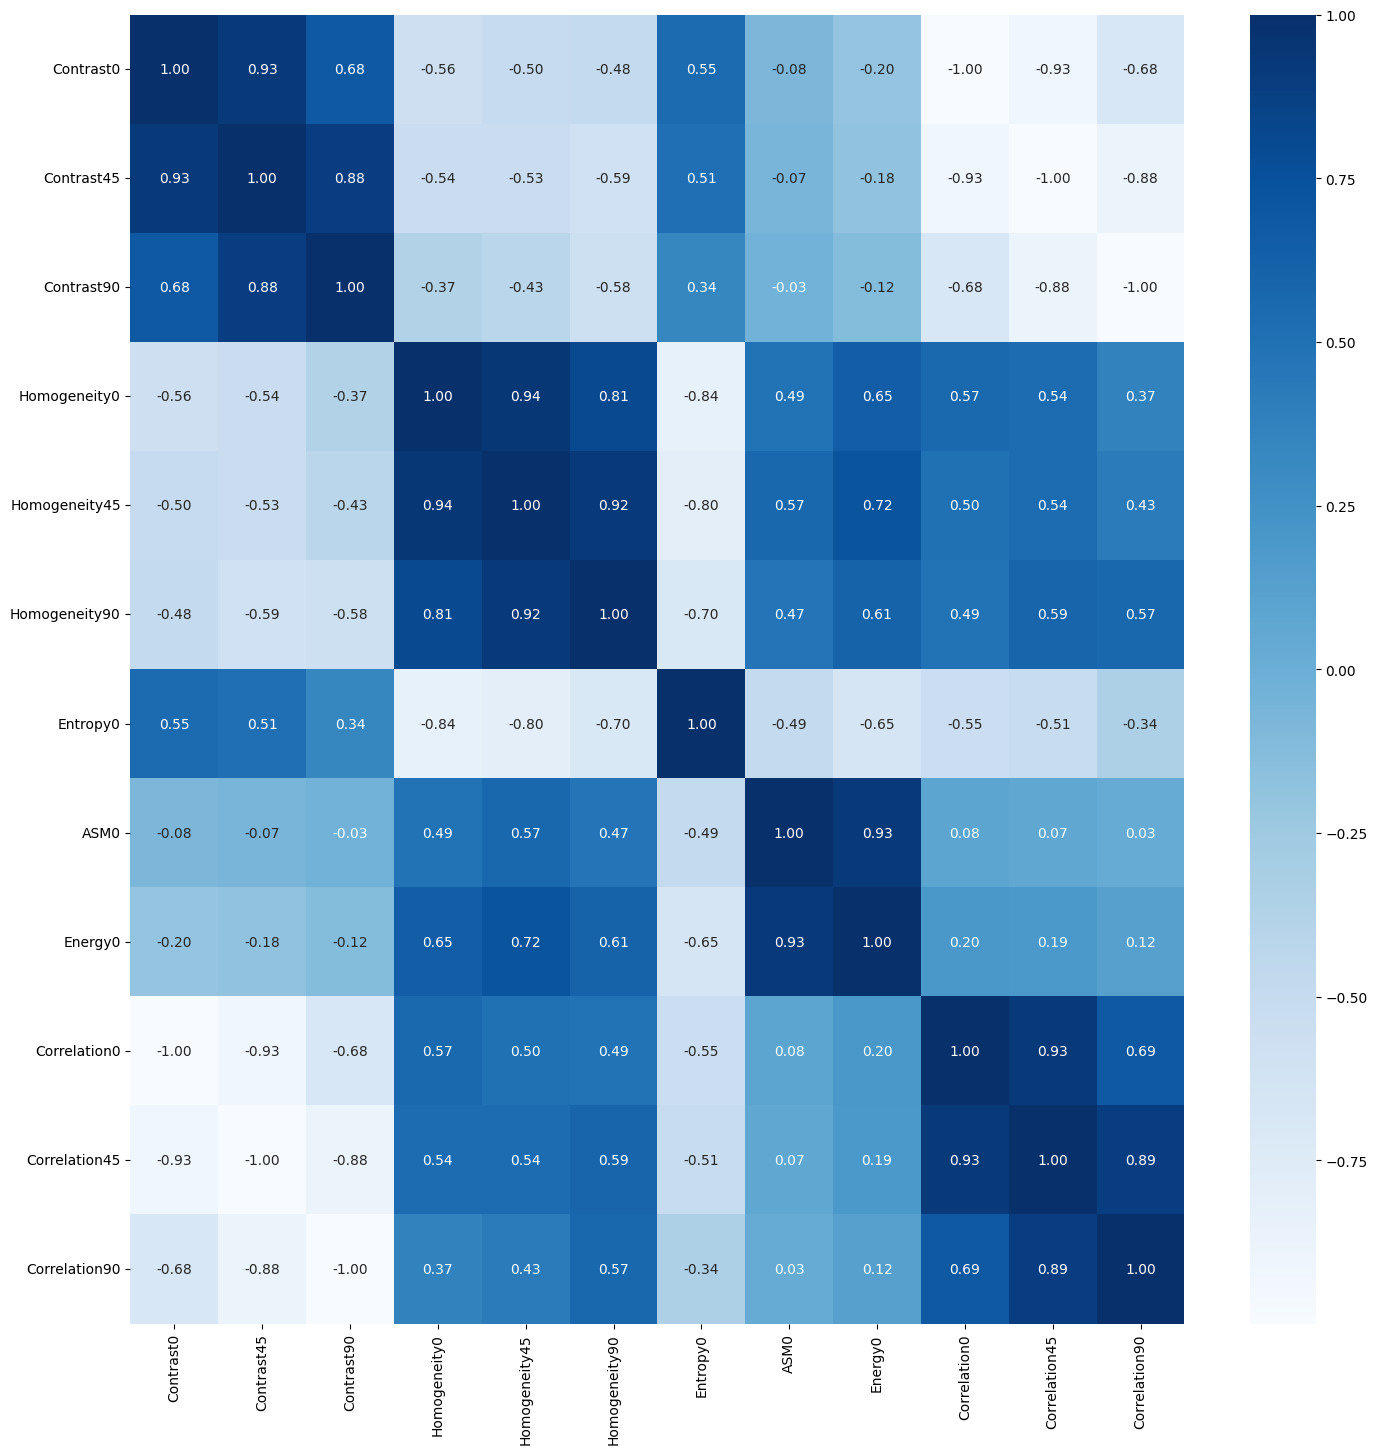

In [38]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [39]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(960, 12)
(240, 12)


In [40]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Fungsi `generateClassificationReport()` menerima data label asli (`y_true`) dan hasil prediksi (`y_pred`), kemudian menampilkan **classification report**, **confusion matrix**, dan nilai **accuracy** untuk mengukur performa model. Setelah itu, didefinisikan tiga classifier, yaitu **Random Forest** (`rf`) dengan 100 pohon keputusan, **Support Vector Machine (SVM)** (`svm`) dengan kernel RBF, dan **K-Nearest Neighbors (KNN)** (`knn`) dengan jumlah tetangga terdekat sebanyak 3. Ketiga model ini nantinya digunakan untuk membandingkan kinerja klasifikasi berdasarkan fitur tekstur GLCM yang telah diekstraksi.

In [41]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

In [42]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       1.00      1.00      1.00       478
 Normal_Skin       1.00      1.00      1.00       482

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960

[[478   0]
 [  0 482]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.95      0.91      0.93       122
 Normal_Skin       0.91      0.95      0.93       118

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240

[[111  11]
 [  6 112]]
Accuracy: 0.9291666666666667


In [43]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.75      0.89      0.81       478
 Normal_Skin       0.87      0.70      0.78       482

    accuracy                           0.80       960
   macro avg       0.81      0.80      0.79       960
weighted avg       0.81      0.80      0.79       960

[[426  52]
 [144 338]]
Accuracy: 0.7958333333333333

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.72      0.87      0.79       122
 Normal_Skin       0.83      0.64      0.72       118

    accuracy                           0.76       240
   macro avg       0.77      0.76      0.75       240
weighted avg       0.77      0.76      0.76       240

[[106  16]
 [ 42  76]]
Accuracy: 0.7583333333333333


In [44]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.94      0.96      0.95       478
 Normal_Skin       0.96      0.94      0.95       482

    accuracy                           0.95       960
   macro avg       0.95      0.95      0.95       960
weighted avg       0.95      0.95      0.95       960

[[461  17]
 [ 30 452]]
Accuracy: 0.9510416666666667

------Testing Set------
              precision    recall  f1-score   support

  Lumpy_Skin       0.87      0.87      0.87       122
 Normal_Skin       0.86      0.86      0.86       118

    accuracy                           0.87       240
   macro avg       0.87      0.87      0.87       240
weighted avg       0.87      0.87      0.87       240

[[106  16]
 [ 16 102]]
Accuracy: 0.8666666666666667


Kode ini digunakan untuk **menampilkan Confusion Matrix** dari hasil prediksi model klasifikasi. Fungsi `plot_confusion_matrix()` menerima label sebenarnya (`y_true`), label hasil prediksi (`y_pred`), dan judul grafik (`title`). Di dalam fungsi, confusion matrix dihitung menggunakan `confusion_matrix()`, kemudian divisualisasikan dengan `ConfusionMatrixDisplay` dalam bentuk grafik berwarna biru. Setelah fungsi dibuat, confusion matrix ditampilkan untuk tiga model klasifikasi, yaitu **Random Forest**, **SVM**, dan **KNN**, menggunakan data uji (`X_test` dan `y_test`). Visualisasi ini membantu melihat jumlah prediksi yang benar dan salah pada setiap kelas sehingga performa masing-masing model dapat dibandingkan dengan lebih mudah.

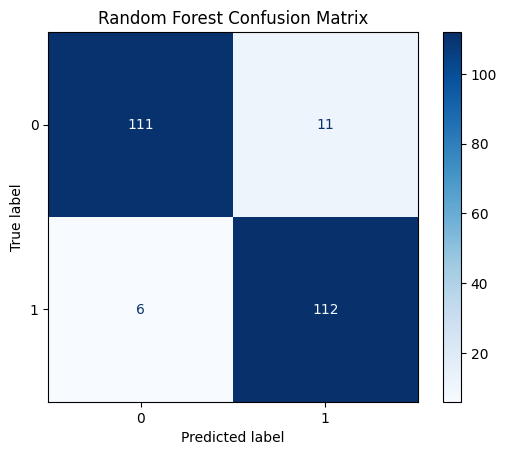

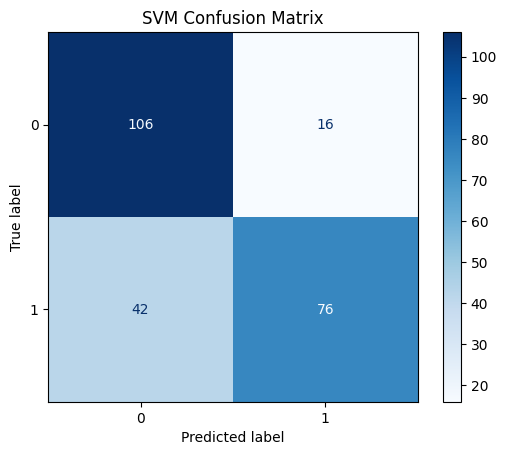

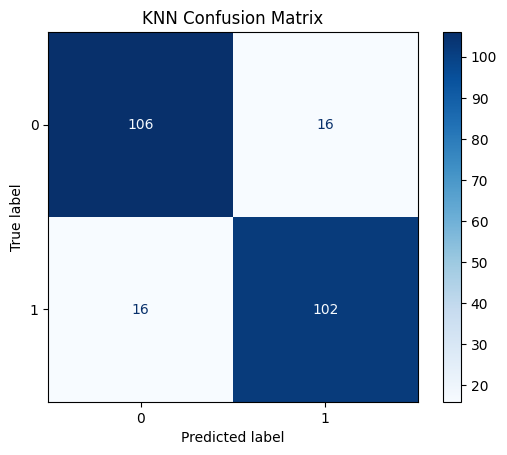

In [45]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

Berdasarkan hasil percobaan yang dilakukan, algoritma **Random Forest** menunjukkan performa terbaik dalam mengklasifikasikan citra kulit sapi menjadi kategori **Lumpy Skin** dan **Normal Skin**. Pada data training, Random Forest memperoleh akurasi sebesar **100%**, sedangkan pada data testing mencapai **92,92%**. Hasil ini menunjukkan bahwa model mampu mengenali pola tekstur citra dengan sangat baik. Selain itu, nilai precision, recall, dan F1-score pada kedua kelas berada di kisaran **92–93%**, sehingga kesalahan klasifikasi yang terjadi relatif sedikit. Dari confusion matrix terlihat bahwa hanya sebagian kecil data yang salah diprediksi, sehingga algoritma ini memiliki tingkat keandalan yang tinggi untuk proses klasifikasi.

Algoritma **K-Nearest Neighbor (KNN)** menempati urutan kedua dengan akurasi training sebesar **95,10%** dan akurasi testing sebesar **86,67%**. Nilai precision dan recall pada kedua kelas juga cukup seimbang, yaitu sekitar **86–87%**. Hal ini menunjukkan bahwa KNN mampu melakukan klasifikasi dengan baik dan menghasilkan performa yang cukup stabil. Namun, jumlah kesalahan prediksi masih lebih banyak dibandingkan Random Forest, sehingga tingkat akurasinya lebih rendah.

Sementara itu, algoritma **Support Vector Machine (SVM)** memberikan hasil yang paling rendah dibandingkan kedua algoritma lainnya. Akurasi training yang diperoleh sebesar **79,58%**, sedangkan akurasi testing hanya mencapai **75,83%**. Meskipun SVM cukup baik dalam mendeteksi kelas Lumpy Skin, model ini mengalami kesulitan dalam mengenali kelas Normal Skin, yang terlihat dari nilai recall kelas Normal yang lebih rendah. Akibatnya, jumlah kesalahan klasifikasi pada confusion matrix menjadi lebih banyak dibandingkan Random Forest maupun KNN.

Secara keseluruhan, dapat disimpulkan bahwa **Random Forest merupakan algoritma yang paling cocok digunakan pada penelitian ini** karena memiliki akurasi tertinggi, nilai precision dan recall yang seimbang, serta jumlah kesalahan klasifikasi yang paling sedikit. Urutan performa algoritma berdasarkan hasil pengujian adalah **Random Forest, KNN, dan SVM**. Dengan demikian, Random Forest menjadi pilihan terbaik untuk klasifikasi citra kulit sapi menggunakan fitur tekstur GLCM pada dataset yang digunakan dalam percobaan ini.